In [ ]:
import os

from huggingface_hub import login

token = os.getenv("HF_TOKEN")
if token:
    login(token=token)


In [8]:

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from datasets import load_dataset

In [9]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [10]:
dataset = load_dataset("imdb")
train_dataset = dataset["train"].shuffle(seed=seed).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=seed).select(range(1000))

print(train_dataset[0])


{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


In [11]:

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


In [12]:
def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

Map: 100%|██████████| 1000/1000 [00:00<00:00, 5403.80 examples/s]


In [13]:

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9252.79it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [14]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8
)


In [15]:

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 2

losses = []



model.train()

for epoch in range(epochs):
    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

print("Training complete")


Training complete


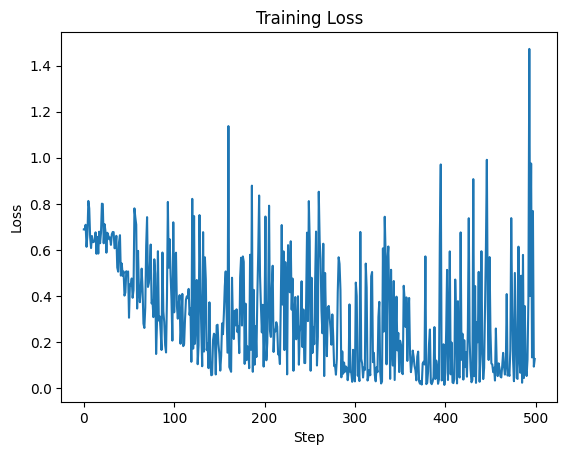

In [16]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f} ({correct}/{total} correct)")



def predict_sentiment(text, model, tokenizer, device):
    """
    Predict sentiment (positive/negative) for a single text using the trained model.

    Args:
        text: Raw input string (e.g., a movie review or sentence).
        model: The trained BERT classification model.
        tokenizer: The tokenizer used during training (same as model).
        device: torch device (cuda/cpu/mps) where the model lives.

    Returns:
        predicted_label: 0 (negative) or 1 (positive).
        probability: Confidence for the predicted class (0 to 1).
    """
    model.eval()
    # Tokenize exactly like in training: same max_length and padding
    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True, # ensures that if the input text is longer than max_length, it will be truncated to fit the model's input size
        max_length=256,
        return_tensors="pt" # returns PyTorch tensors directly, which can be fed into the model without additional conversion
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    # Logits are raw scores; we take the predicted class and its probability
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    predicted_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_id].item()

    return predicted_id, confidence


# --- Get input from the user and print the result ---
user_text = input("Enter a movie review or any sentence to analyze sentiment: ").strip()

if user_text:
    pred_label, confidence = predict_sentiment(user_text, model, tokenizer, device)
    sentiment_str = "Positive" if pred_label == 1 else "Negative"
    print(f"\nPrediction: {sentiment_str}")
    print(f"Confidence: {confidence:.2%}")
else:
    print("No text entered.")

Test accuracy: 0.8640 (864/1000 correct)

Prediction: Positive
Confidence: 88.29%
